# SHAP, Control de Overfitting, Calibración y Umbral

## Configuración

In [18]:
import warnings, os, json, time
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     cross_val_score, cross_val_predict, learning_curve)
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, ExtraTreesClassifier,
                              HistGradientBoostingClassifier)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (f1_score, accuracy_score, precision_score, recall_score,
                             roc_auc_score, confusion_matrix, precision_recall_curve,
                             roc_curve, auc, silhouette_score, brier_score_loss)
from imblearn.over_sampling import RandomOverSampler, SMOTE, BorderlineSMOTE, ADASYN
from imblearn.combine import SMOTETomek
from imblearn.pipeline import Pipeline as ImbPipeline
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier
import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)
import shap

SEED = 42
np.random.seed(SEED)
plt.rcParams['figure.dpi'] = 110
sns.set_style('whitegrid')

# ---- Datos y split (idénticos a Sprints 0-2) ----
df = pd.read_csv('../data/processed/data_procesada.csv')
EXCLUIR = ['Au_ppm', 'target_Au', 'East', 'North', 'Level']
FEATURES_BASE = [c for c in df.columns if c not in EXCLUIR]
X = df[FEATURES_BASE].copy()
y = df['target_Au'].astype(int).copy()
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED)
CV5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# ---- Resultados del Sprint 2 ----
with open('outputs_sprint2/resumen_sprint2.json') as f:
    RESUMEN_S2 = json.load(f)

MODELO_GANADOR = RESUMEN_S2['mejor_modelo']
SET_GANADOR    = RESUMEN_S2['mejor_set']
CONFIG_FINAL_S2 = RESUMEN_S2['config_final']
BALANCEO_GANADOR = RESUMEN_S2['metodo_balanceo']
F1_SPRINT2     = RESUMEN_S2['f1_final']
F1_SPRINT1     = RESUMEN_S2['f1_sprint1']
F1_SPRINT0     = RESUMEN_S2['f1_sprint0']
FEATURES_SET_GANADOR = RESUMEN_S2['features_set_ganador']
FEATURES_CLU_S2 = RESUMEN_S2.get('features_clustering', [])
RATIOS_S2       = RESUMEN_S2.get('ratios_seleccionados', {})

# Parámetros del ganador: defaults si «Mejor experimento», Optuna si «+ Optuna»
if CONFIG_FINAL_S2 == '+ Optuna':
    PARAMS_GANADOR = dict(RESUMEN_S2['best_params_optuna'])
else:
    PARAMS_GANADOR = {}

os.makedirs('outputs_sprint3', exist_ok=True)
print(f'Ganador Sprint 2: {MODELO_GANADOR} | set={SET_GANADOR} | config={CONFIG_FINAL_S2}')
print(f'  Balanceo: {BALANCEO_GANADOR} | F1 Sprint 2: {F1_SPRINT2}')
print(f'  Params: {PARAMS_GANADOR if PARAMS_GANADOR else "(defaults)"}')
print(f'  Features del set ganador: {len(FEATURES_SET_GANADOR)}')

Ganador Sprint 2: HistGradientBoosting | set=E3 +Cluster | config=Mejor experimento
  Balanceo: RandomOverSampler | F1 Sprint 2: 0.8224
  Params: (defaults)
  Features del set ganador: 51


## Funciones

In [19]:
METRICAS = ['F1', 'Accuracy', 'Precision', 'Recall', 'AUC-ROC']

def crear_balanceador(nombre):
    '''Instancia nueva del balanceador.'''
    return {
        'Sin balanceo':      None,
        'RandomOverSampler': RandomOverSampler(random_state=SEED),
        'SMOTE':             SMOTE(random_state=SEED, k_neighbors=5),
        'BorderlineSMOTE':   BorderlineSMOTE(random_state=SEED, k_neighbors=5),
        'ADASYN':            ADASYN(random_state=SEED),
        'SMOTETomek':        SMOTETomek(random_state=SEED),
    }[nombre]

def crear_clf(mod=None, params=None):
    '''Clasificador sin pipeline.'''
    mod = mod or MODELO_GANADOR
    p = params if params is not None else PARAMS_GANADOR
    constructors = {
        'KNN':                  lambda: KNeighborsClassifier(**(p or {})),
        'Reg. Logística':       lambda: LogisticRegression(max_iter=2000, random_state=SEED, **p),
        'SVM (RBF)':            lambda: SVC(kernel='rbf', probability=True, random_state=SEED, **p),
        'MLP':                  lambda: MLPClassifier(max_iter=500, random_state=SEED, **p),
        'Árbol de Decisión':    lambda: DecisionTreeClassifier(random_state=SEED, **p),
        'Random Forest':        lambda: RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1, **p),
        'ExtraTrees':           lambda: ExtraTreesClassifier(n_estimators=100, random_state=SEED, n_jobs=-1, **p),
        'HistGradientBoosting': lambda: HistGradientBoostingClassifier(random_state=SEED, **p),
        'XGBoost':              lambda: xgb.XGBClassifier(random_state=SEED, eval_metric='logloss',
                                                          tree_method='hist', n_jobs=-1, **p),
        'LightGBM':             lambda: lgb.LGBMClassifier(n_estimators=100, random_state=SEED,
                                                           verbose=-1, n_jobs=-1, **p),
        'CatBoost':             lambda: CatBoostClassifier(iterations=100, random_seed=SEED, verbose=0, **p),
    }
    return constructors[mod]()

def crear_imbpipeline(params=None, mod=None):
    '''ImbPipeline: scaler -> balanceo (dentro de cada fold) -> clasificador.'''
    steps = [('sc', StandardScaler())]
    bal = crear_balanceador(BALANCEO_GANADOR)
    if bal is not None:
        steps.append(('bal', bal))
    steps.append(('clf', crear_clf(mod, params)))
    return ImbPipeline(steps)

def f1_cv(Xtr_s, params=None, mod=None, cv=None):
    '''F1 medio en CV con ImbPipeline (balanceo dentro de cada fold).'''
    cv = cv or CV5
    pipe = crear_imbpipeline(params, mod)
    return float(np.mean(cross_val_score(pipe, Xtr_s, y_train, scoring='f1', cv=cv, n_jobs=-1)))

def entrenar_evaluar(Xtr, Xte, params=None, mod=None, umbral=0.5):
    '''Entrena ImbPipeline y evalúa en hold-out.'''
    modelo = crear_imbpipeline(params, mod)
    modelo.fit(Xtr, y_train)
    prob = modelo.predict_proba(Xte)[:, 1]
    pred = (prob >= umbral).astype(int)
    return {'F1': f1_score(y_test, pred), 'Accuracy': accuracy_score(y_test, pred),
            'Precision': precision_score(y_test, pred, zero_division=0),
            'Recall': recall_score(y_test, pred), 'AUC-ROC': roc_auc_score(y_test, prob),
            '_pred': pred, '_prob': prob, '_clf': modelo}
print('Funciones listas.')

Funciones listas.


## Modelo ganador del Sprint 2

In [20]:
# ---- FE: ratios dirigidos + log1p (mismos del Sprint 2) ----
skews = X_train.skew().sort_values(ascending=False)
COLS_LOG = list(skews[skews > 2].index)

def aplicar_fe(Xdf, medianas=None):
    out = Xdf.copy()
    for nom, (nu, de) in RATIOS_S2.items():
        out[nom] = (Xdf[nu] / Xdf[de].replace(0, np.nan)).replace([np.inf, -np.inf], np.nan)
    for c in COLS_LOG:
        out[f'log_{c}'] = np.log1p(Xdf[c].clip(lower=0))
    cols_ratio = list(RATIOS_S2)
    if medianas is None:
        medianas = out[cols_ratio].median()
    out[cols_ratio] = out[cols_ratio].fillna(medianas)
    return out, medianas

X_train_fe, MED_TRAIN = aplicar_fe(X_train)
X_test_fe, _ = aplicar_fe(X_test, MED_TRAIN)

# ---- Clustering (solo si el set ganador incluye features de cluster) ----
needs_clu = any(f in FEATURES_CLU_S2 for f in FEATURES_SET_GANADOR)
if needs_clu:
    clu_base = X_train_fe if 'FE' in SET_GANADOR else X_train
    clu_base_te = X_test_fe if 'FE' in SET_GANADOR else X_test
    # Espacio de clustering del Sprint 2 (sin elementos económicos), leído del JSON
    clave_cols = 'cols_espacio_clustering_fe' if 'FE' in SET_GANADOR else 'cols_espacio_clustering_base'
    non_clu_cols = RESUMEN_S2.get(clave_cols) or [c for c in clu_base.columns if c not in FEATURES_CLU_S2]
    non_clu_cols = [c for c in non_clu_cols if c in clu_base.columns]
    sc_clu = StandardScaler().fit(clu_base[non_clu_cols])
    Xtr_sc = sc_clu.transform(clu_base[non_clu_cols])
    Xte_sc = sc_clu.transform(clu_base_te[non_clu_cols])
    ks = range(2, 11)
    silus = [silhouette_score(Xtr_sc, KMeans(n_clusters=k, random_state=SEED, n_init=10)
                              .fit_predict(Xtr_sc)) for k in ks]
    from sklearn.mixture import GaussianMixture
    from sklearn.cluster import DBSCAN
    k_km = list(ks)[int(np.argmax(silus))]
    bics = [GaussianMixture(n_components=k, random_state=SEED, n_init=3).fit(Xtr_sc).bic(Xtr_sc) for k in ks]
    k_gm = list(ks)[int(np.argmin(bics))]
    eps = float(np.percentile(np.sort(NearestNeighbors(n_neighbors=5).fit(Xtr_sc)
                                      .kneighbors(Xtr_sc)[0][:, -1]), 90))
    km = KMeans(n_clusters=k_km, random_state=SEED, n_init=10).fit(Xtr_sc)
    gm = GaussianMixture(n_components=k_gm, random_state=SEED, n_init=3).fit(Xtr_sc)
    db = DBSCAN(eps=eps, min_samples=5).fit(Xtr_sc)
    nn_core = NearestNeighbors(n_neighbors=1).fit(Xtr_sc[db.core_sample_indices_])
    def _clu_feats(Xsc, idx):
        return pd.DataFrame({
            'kmeans_label': km.predict(Xsc), 'kmeans_dist': km.transform(Xsc).min(axis=1),
            'gmm_label': gm.predict(Xsc), 'gmm_prob_max': gm.predict_proba(Xsc).max(axis=1),
            'dbscan_outlier': (nn_core.kneighbors(Xsc)[0][:, 0] > eps).astype(int),
        }, index=idx)
    X_train_fe = pd.concat([X_train_fe, _clu_feats(Xtr_sc, X_train.index)], axis=1)
    X_test_fe = pd.concat([X_test_fe, _clu_feats(Xte_sc, X_test.index)], axis=1)
    print(f'Clusters reconstruidos (k_km={k_km}, k_gm={k_gm}, eps={eps:.2f})')

# ---- Selección de columnas del set ganador ----
missing = [f for f in FEATURES_SET_GANADOR if f not in X_train_fe.columns]
if missing:
    print(f'Features no reconstruidas (omitidas): {missing}')
    FEATURES_SET_GANADOR = [f for f in FEATURES_SET_GANADOR if f in X_train_fe.columns]
XTR = X_train_fe[FEATURES_SET_GANADOR].copy()
XTE = X_test_fe[FEATURES_SET_GANADOR].copy()
print(f'Set reconstruido ({SET_GANADOR}): {XTR.shape[1]} features')

# ---- Baseline: evaluar el ganador reconstruido ----
F1_CV_BASE = f1_cv(XTR)
RES_BASE = entrenar_evaluar(XTR, XTE)
print(f'Ganador Sprint 2 reconstruido: F1 CV = {F1_CV_BASE:.4f} | '
      f'F1 hold-out = {RES_BASE["F1"]:.4f} (original: {F1_SPRINT2})')

Clusters reconstruidos (k_km=4, k_gm=5, eps=4.54)
Set reconstruido (E3 +Cluster): 51 features
Ganador Sprint 2 reconstruido: F1 CV = 0.7278 | F1 hold-out = 0.8224 (original: 0.8224)


## Diagnostico Learning Curves

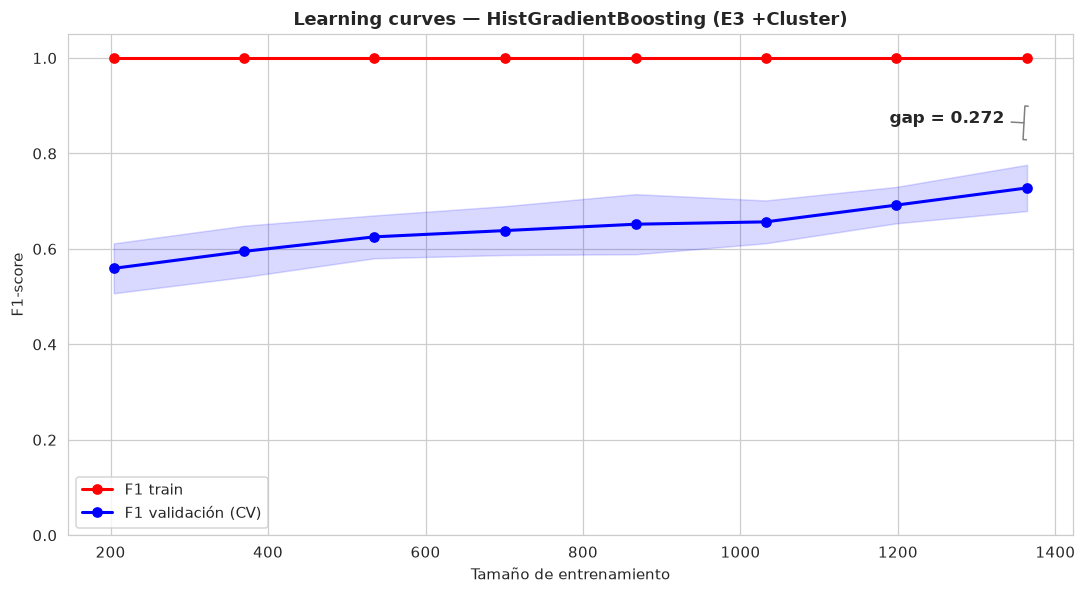

F1 train (100% datos): 1.0000 | F1 validación: 0.7278 | GAP: 0.2722
Diagnóstico: OVERFITTING marcado: gap > 0.15 -> priorizar regularización


In [21]:
modelo_lc = crear_imbpipeline()
sizes, tr_scores, va_scores = learning_curve(
    modelo_lc, XTR, y_train, cv=CV5, scoring='f1',
    train_sizes=np.linspace(0.15, 1.0, 8), n_jobs=-1, random_state=SEED)
tr_mu, tr_sd = tr_scores.mean(1), tr_scores.std(1)
va_mu, va_sd = va_scores.mean(1), va_scores.std(1)

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(sizes, tr_mu, 'o-', color='red', lw=2, label='F1 train')
ax.fill_between(sizes, tr_mu - tr_sd, tr_mu + tr_sd, alpha=0.15, color='red')
ax.plot(sizes, va_mu, 'o-', color='blue', lw=2, label='F1 validación (CV)')
ax.fill_between(sizes, va_mu - va_sd, va_mu + va_sd, alpha=0.15, color='blue')
gap_final = tr_mu[-1] - va_mu[-1]
ax.annotate(f'gap = {gap_final:.3f}', xy=(sizes[-1], (tr_mu[-1] + va_mu[-1]) / 2),
            xytext=(-90, 0), textcoords='offset points', fontsize=11, fontweight='bold',
            arrowprops=dict(arrowstyle='-[', color='gray'))
ax.set_xlabel('Tamaño de entrenamiento'); ax.set_ylabel('F1-score'); ax.set_ylim(0, 1.05)
ax.set_title(f'Learning curves — {MODELO_GANADOR} ({SET_GANADOR})', fontweight='bold')
ax.legend()
plt.tight_layout(); plt.savefig('outputs_sprint3/learning_curves_ganador.png', bbox_inches='tight'); plt.show()

print(f'F1 train (100% datos): {tr_mu[-1]:.4f} | F1 validación: {va_mu[-1]:.4f} | GAP: {gap_final:.4f}')
diag = ('OVERFITTING marcado: gap > 0.15 -> priorizar regularización' if gap_final > 0.15 else
        'Gap moderado: algo de sobreajuste' if gap_final > 0.08 else
        'Gap bajo: el modelo generaliza bien')
print('Diagnóstico:', diag)

In [22]:
clf_gap = crear_imbpipeline()
clf_gap.fit(XTR, y_train)
f1_train_full = f1_score(y_train, clf_gap.predict(XTR))
tabla_gap = pd.DataFrame({
    'Conjunto': ['Train (resustitución)', 'CV 5-fold (train)', 'Hold-out (20%)'],
    'F1': [round(f1_train_full, 4), round(F1_CV_BASE, 4), round(RES_BASE['F1'], 4)]})
tabla_gap['Gap vs train'] = (tabla_gap['F1'] - f1_train_full).round(4)
tabla_gap.to_csv('outputs_sprint3/gap_diagnostico.csv', index=False)
display(tabla_gap)
print(f'|CV − hold-out| = {abs(F1_CV_BASE - RES_BASE["F1"]):.4f} -> '
      f'{"consistente" if abs(F1_CV_BASE - RES_BASE["F1"]) < 0.06 else "brecha a vigilar"}')

,Conjunto,F1,Gap vs train
0,Train (resustitución),1.0000,0.0000
1,CV 5-fold (train),0.7278,-0.2722
2,Hold-out (20%),0.8224,-0.1776


|CV − hold-out| = 0.0946 -> brecha a vigilar


## SHAP

Usando TreeExplainer (0.1s)
SHAP values del hold-out calculados: (427, 51)


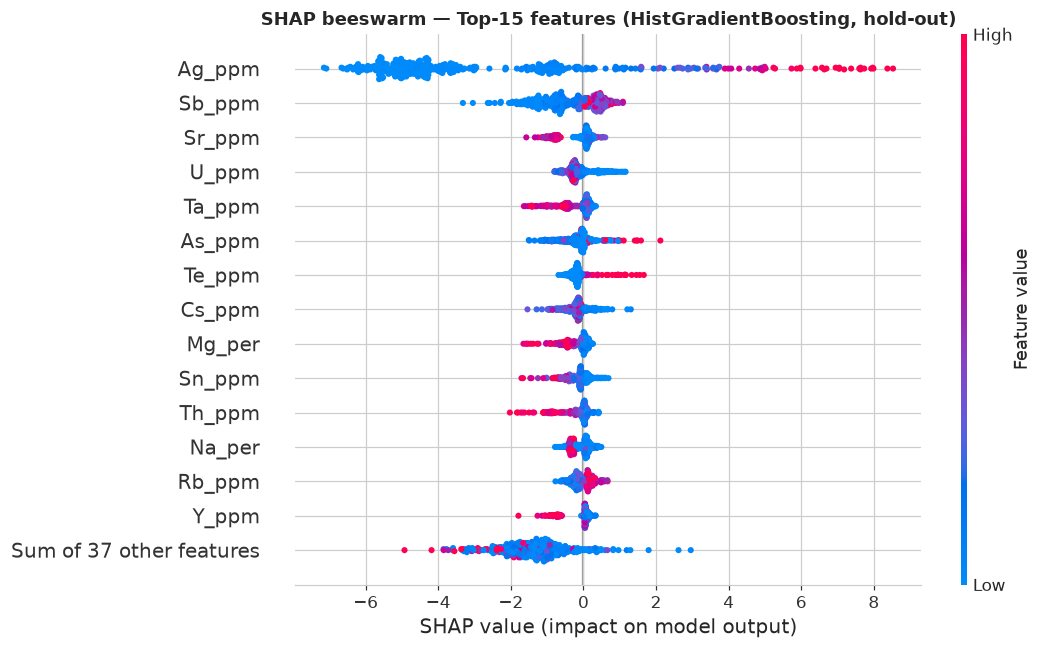

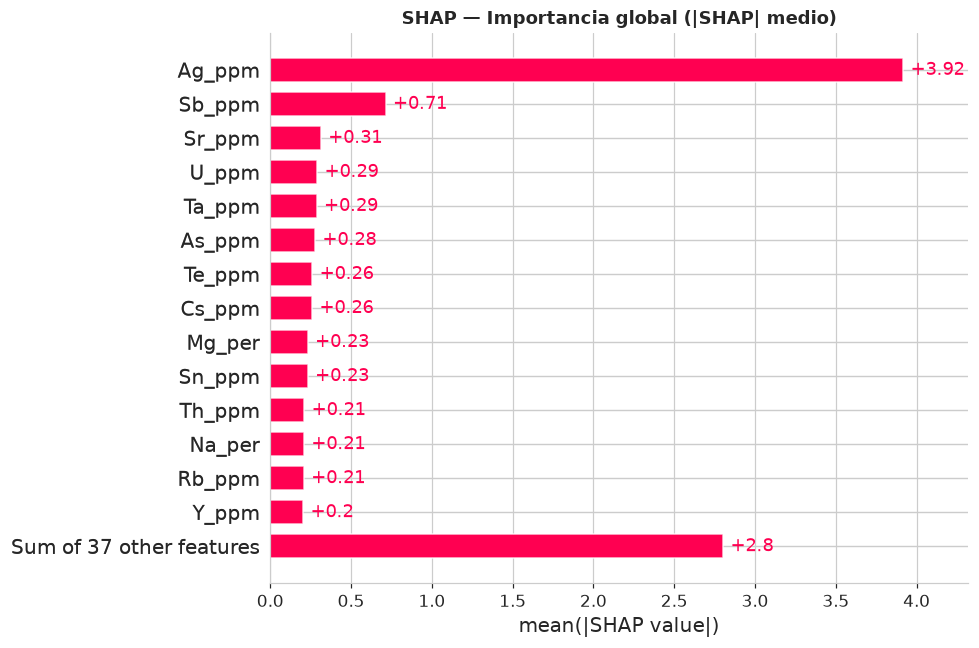


Top-10 features por |SHAP| medio:


,|SHAP| medio
Ag_ppm,3.9169
Sb_ppm,0.7136
Sr_ppm,0.3129
U_ppm,0.2900
Ta_ppm,0.2868
As_ppm,0.2769
Te_ppm,0.2597
Cs_ppm,0.2586
Mg_per,0.2317
Sn_ppm,0.2316


In [23]:
# Entrenar modelo para SHAP (usando pipeline: scaler + balanceo + clf)
modelo_shap = crear_imbpipeline()
modelo_shap.fit(XTR, y_train)
scaler_fit = modelo_shap.named_steps['sc']
clf_fit = modelo_shap.named_steps['clf']

# Escalar datos (el clf fue entrenado sobre datos escalados)
X_train_sc = pd.DataFrame(scaler_fit.transform(XTR), columns=XTR.columns, index=XTR.index)
X_test_sc  = pd.DataFrame(scaler_fit.transform(XTE), columns=XTE.columns, index=XTE.index)

# Explainer
t0 = time.time()
try:
    explainer = shap.TreeExplainer(clf_fit)
    print(f'Usando TreeExplainer ({time.time()-t0:.1f}s)')
except Exception:
    explainer = shap.Explainer(clf_fit, X_train_sc.sample(min(100, len(X_train_sc)), random_state=SEED))
    print(f'Usando Explainer genérico ({time.time()-t0:.1f}s)')

sv_test = explainer(X_test_sc)
print(f'SHAP values del hold-out calculados: {sv_test.shape}')

# ---- Beeswarm (top-15) ----
shap.plots.beeswarm(sv_test, max_display=15, show=False)
plt.gcf().set_size_inches(10, 6)
plt.title(f'SHAP beeswarm — Top-15 features ({MODELO_GANADOR}, hold-out)', fontweight='bold')
plt.tight_layout(); plt.savefig('outputs_sprint3/shap_beeswarm.png', bbox_inches='tight'); plt.show()

# ---- Barras: |SHAP| medio global ----
shap.plots.bar(sv_test, max_display=15, show=False)
plt.gcf().set_size_inches(9, 6)
plt.title(f'SHAP — Importancia global (|SHAP| medio)', fontweight='bold')
plt.tight_layout(); plt.savefig('outputs_sprint3/shap_bar.png', bbox_inches='tight'); plt.show()

# Guardar importancias SHAP
imp_shap = pd.Series(np.abs(sv_test.values).mean(0), index=XTR.columns).sort_values(ascending=False)
imp_shap.to_csv('outputs_sprint3/shap_importancias.csv', header=['shap_medio'])
print('\nTop-10 features por |SHAP| medio:')
display(imp_shap.head(10).round(4).to_frame('|SHAP| medio'))

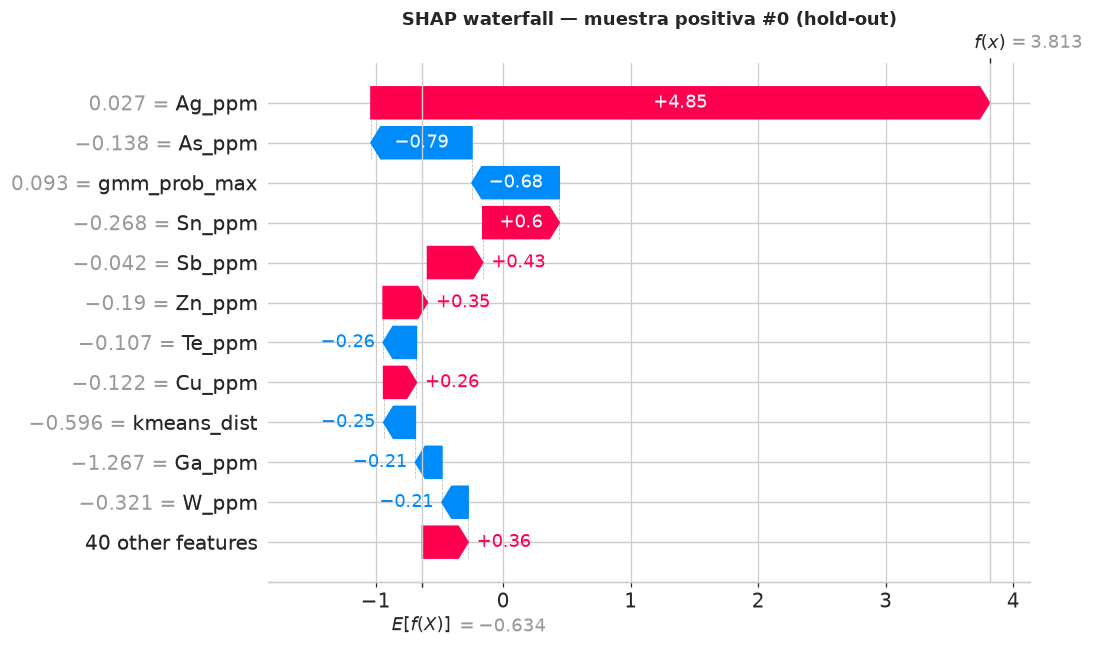

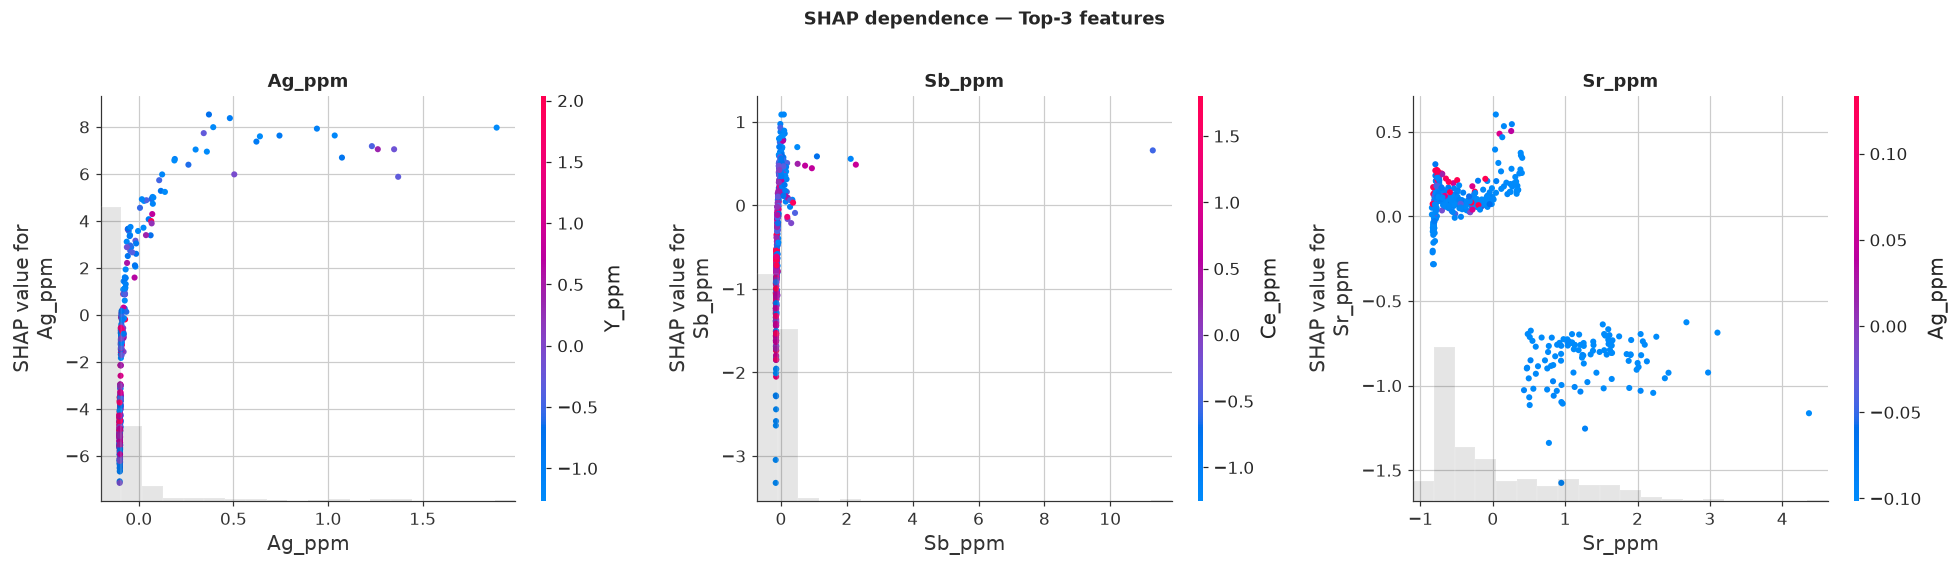

In [24]:
# ---- Waterfall: anatomía de una predicción positiva correcta ----
idx_pos = np.where((y_test.values == 1) & (RES_BASE['_pred'] == 1))[0]
if len(idx_pos) > 0:
    shap.plots.waterfall(sv_test[idx_pos[0]], max_display=12, show=False)
    plt.gcf().set_size_inches(10, 6)
    plt.title(f'SHAP waterfall — muestra positiva #{idx_pos[0]} (hold-out)', fontweight='bold')
    plt.tight_layout(); plt.savefig('outputs_sprint3/shap_waterfall.png', bbox_inches='tight'); plt.show()

# ---- Dependence plots de las 3 features más importantes ----
top3 = imp_shap.head(3).index.tolist()
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax_i, feat in zip(axes, top3):
    shap.plots.scatter(sv_test[:, feat], color=sv_test, ax=ax_i, show=False)
    ax_i.set_title(f'{feat}', fontweight='bold')
plt.suptitle('SHAP dependence — Top-3 features', fontweight='bold', y=1.02)
plt.tight_layout(); plt.savefig('outputs_sprint3/shap_dependence_top3.png', bbox_inches='tight'); plt.show()

## Cluster (SHAP)

SHAP values del train: (1705, 51) (2.0s)

Top-10 features por |SHAP| medio (train):


,|SHAP| medio (train)
Ag_ppm,3.9081
Sb_ppm,0.7275
Sr_ppm,0.3176
U_ppm,0.3059
As_ppm,0.2954
Te_ppm,0.2807
Cs_ppm,0.2649
Ta_ppm,0.2485
Mg_per,0.2271
Sn_ppm,0.2194


Umbral |SHAP| medio (train) = 0.2056
Elementos no-económicos importantes (10): ['Sb_ppm', 'Sr_ppm', 'U_ppm', 'As_ppm', 'Te_ppm', 'Cs_ppm', 'Ta_ppm', 'Mg_per', 'Sn_ppm', 'Rb_ppm']


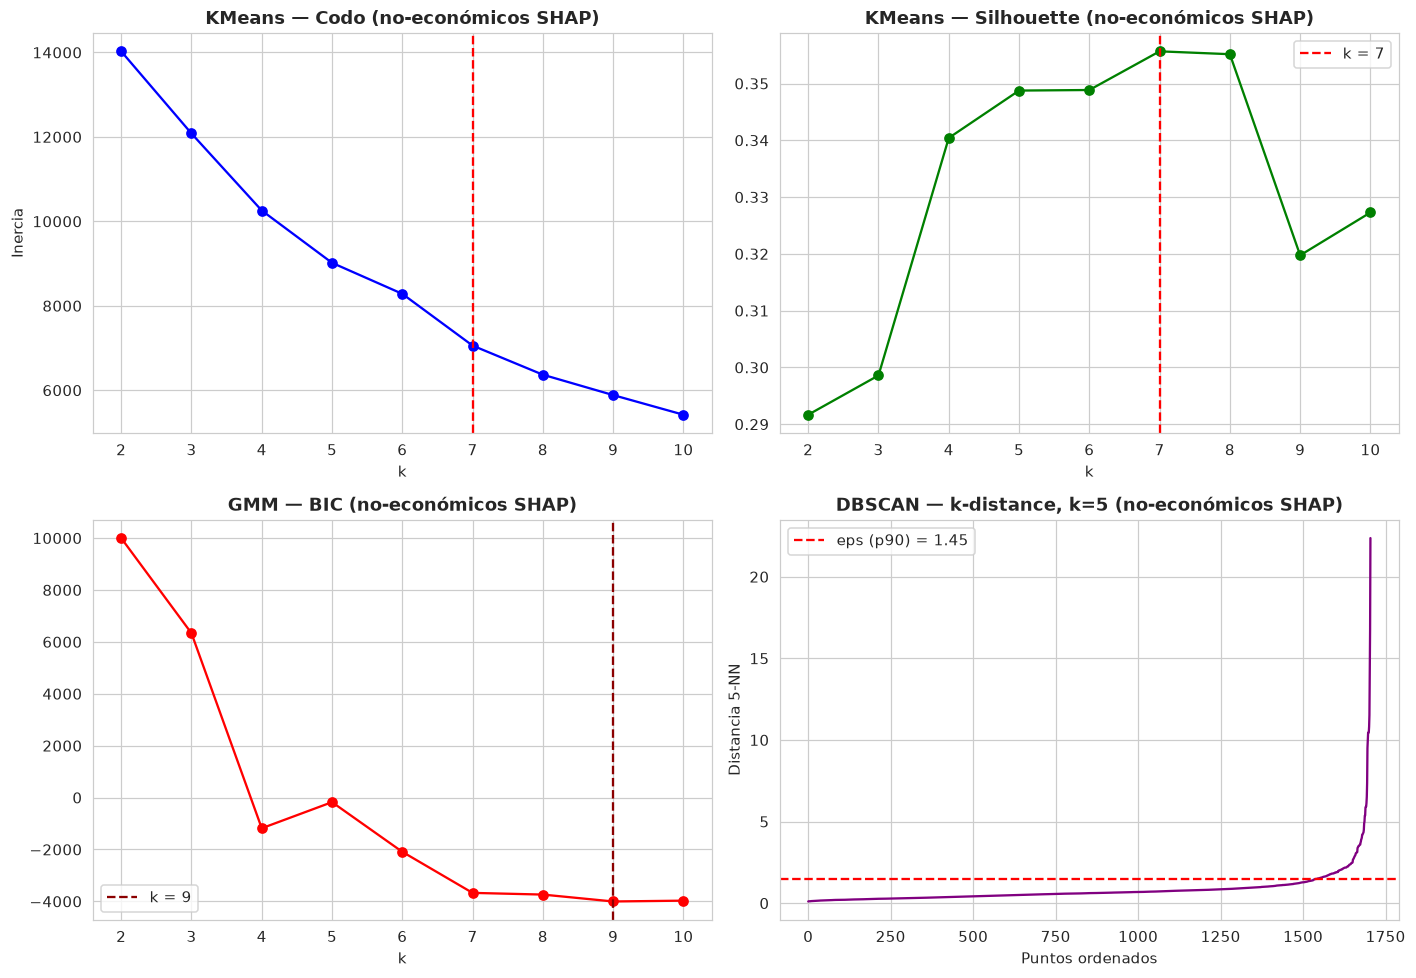

  Silhouettes por k(2..10): [0.292, 0.299, 0.34, 0.349, 0.349, 0.356, 0.355, 0.32, 0.327]

Cluster SHAP → k_km=7, k_gm=9, eps=1.45
Outliers DBSCAN — train: 7.2% | test: 8.7%
Features de cluster SHAP: ['shap_kmeans_label', 'shap_kmeans_dist', 'shap_gmm_label', 'shap_gmm_prob_max', 'shap_dbscan_outlier']

Composición del target por cluster SHAP (train) — tasa base positivos = 0.122:


,n,% Neg,% Pos
kmeans=0,357,0.997,0.003
kmeans=1,741,0.799,0.201
kmeans=2,201,0.990,0.010
kmeans=3,13,0.077,0.923
kmeans=4,8,0.000,1.000
kmeans=5,5,0.800,0.200
kmeans=6,380,0.908,0.092
gmm=0,467,0.949,0.051
gmm=1,85,0.941,0.059
gmm=2,412,0.998,0.002


F1 CV con cluster SHAP = 0.7105 (baseline 0.7278, Δ = -0.0174)
Cluster SHAP NO mejoró F1 CV → se mantiene set base S2

════════ CLUSTER SHAP (Sprint 3) vs GANADOR Sprint 2 ════════
  F1 CV ganador Sprint 2 (reconstruido)  = 0.7278
  F1 CV con cluster SHAP (no-económicos) = 0.7105  (Δ = -0.0174)
  -> el cluster SHAP no mejora sobre el Sprint 2

-> SET BASE para el Paso 2: S2 (51 features, F1 CV = 0.7278)


In [25]:
from sklearn.mixture import GaussianMixture
from sklearn.cluster import DBSCAN

# ---- SHAP del TRAIN (base para clustering SHAP y selección posterior) ----
t0 = time.time()
sv_train = explainer(X_train_sc)
print(f'SHAP values del train: {tuple(sv_train.shape)} ({time.time()-t0:.1f}s)')

imp_shap_train = pd.Series(np.abs(sv_train.values).mean(0), index=XTR.columns).sort_values(ascending=False)
imp_shap_train.to_csv('outputs_sprint3/shap_importancias_train.csv', header=['shap_medio'])
print('\nTop-10 features por |SHAP| medio (train):')
display(imp_shap_train.head(10).round(4).to_frame('|SHAP| medio (train)'))

# ---- Elementos crudos NO económicos importantes por SHAP (train) ----
ELEM_ECON = RESUMEN_S2.get('elementos_economicos_excluidos_fe', ['Ag_ppm', 'Cu_ppm', 'Pb_ppm', 'Zn_ppm'])
UMBRAL_SHAP = float(imp_shap_train.mean())
cand_noecon = [c for c in imp_shap_train.index
               if c in FEATURES_BASE and c not in ELEM_ECON and imp_shap_train[c] >= UMBRAL_SHAP]
print(f'Umbral |SHAP| medio (train) = {UMBRAL_SHAP:.4f}')
print(f'Elementos no-económicos importantes ({len(cand_noecon)}): {cand_noecon}')

def seleccionar_clustering_s3(Xtr, etiqueta, fname):
    # KMeans (codo+silhouette), GMM (BIC) y DBSCAN (k-distance p90) con soporte gráfico
    sc = StandardScaler().fit(Xtr)
    Xtr_sc = sc.transform(Xtr)
    ks = list(range(2, 11))
    inercias, silus, bics = [], [], []
    for k in ks:
        km = KMeans(n_clusters=k, random_state=SEED, n_init=10).fit(Xtr_sc)
        inercias.append(km.inertia_); silus.append(silhouette_score(Xtr_sc, km.labels_))
        bics.append(GaussianMixture(n_components=k, random_state=SEED, n_init=3).fit(Xtr_sc).bic(Xtr_sc))
    k_km = ks[int(np.argmax(silus))]; k_gm = ks[int(np.argmin(bics))]
    d5 = np.sort(NearestNeighbors(n_neighbors=5).fit(Xtr_sc).kneighbors(Xtr_sc)[0][:, -1])
    eps = float(np.percentile(d5, 90))
    fig, axes = plt.subplots(2, 2, figsize=(13, 9))
    axes[0, 0].plot(ks, inercias, marker='o', color='blue'); axes[0, 0].axvline(k_km, ls='--', color='red')
    axes[0, 0].set_title(f'KMeans — Codo ({etiqueta})', fontweight='bold')
    axes[0, 0].set_xlabel('k'); axes[0, 0].set_ylabel('Inercia')
    axes[0, 1].plot(ks, silus, marker='o', color='green')
    axes[0, 1].axvline(k_km, ls='--', color='red', label=f'k = {k_km}')
    axes[0, 1].set_title(f'KMeans — Silhouette ({etiqueta})', fontweight='bold')
    axes[0, 1].set_xlabel('k'); axes[0, 1].legend()
    axes[1, 0].plot(ks, bics, marker='o', color='red')
    axes[1, 0].axvline(k_gm, ls='--', color='darkred', label=f'k = {k_gm}')
    axes[1, 0].set_title(f'GMM — BIC ({etiqueta})', fontweight='bold')
    axes[1, 0].set_xlabel('k'); axes[1, 0].legend()
    axes[1, 1].plot(d5, color='purple')
    axes[1, 1].axhline(eps, ls='--', color='red', label=f'eps (p90) = {eps:.2f}')
    axes[1, 1].set_title(f'DBSCAN — k-distance, k=5 ({etiqueta})', fontweight='bold')
    axes[1, 1].set_xlabel('Puntos ordenados'); axes[1, 1].set_ylabel('Distancia 5-NN'); axes[1, 1].legend()
    plt.tight_layout(); plt.savefig(fname, bbox_inches='tight'); plt.show()
    print(f'  Silhouettes por k(2..10): {[round(s, 3) for s in silus]}')
    return {'scaler': sc, 'k_kmeans': k_km, 'silhouette': float(max(silus)), 'k_gmm': k_gm, 'eps': eps}

def derivar_clustering_s3(sel, Xtr, Xte):
    Xtr_sc = sel['scaler'].transform(Xtr); Xte_sc = sel['scaler'].transform(Xte)
    km = KMeans(n_clusters=sel['k_kmeans'], random_state=SEED, n_init=10).fit(Xtr_sc)
    gm = GaussianMixture(n_components=sel['k_gmm'], random_state=SEED, n_init=3).fit(Xtr_sc)
    db = DBSCAN(eps=sel['eps'], min_samples=5).fit(Xtr_sc)
    cores = Xtr_sc[db.core_sample_indices_] if len(db.core_sample_indices_) else Xtr_sc
    nn_core = NearestNeighbors(n_neighbors=1).fit(cores)
    def feats(Xsc, idx):
        return pd.DataFrame({
            'shap_kmeans_label':   km.predict(Xsc),
            'shap_kmeans_dist':    km.transform(Xsc).min(axis=1),
            'shap_gmm_label':      gm.predict(Xsc),
            'shap_gmm_prob_max':   gm.predict_proba(Xsc).max(axis=1),
            'shap_dbscan_outlier': (nn_core.kneighbors(Xsc)[0][:, 0] > sel['eps']).astype(int),
        }, index=idx)
    return feats(Xtr_sc, Xtr.index), feats(Xte_sc, Xte.index)

def composicion_target(clu_tr, y):
    # Composición del target por cada método de clustering (KMeans, GMM, DBSCAN), como en el Sprint 2
    filas = []
    for metodo in ['shap_kmeans_label', 'shap_gmm_label', 'shap_dbscan_outlier']:
        ct = pd.crosstab(clu_tr[metodo], y, normalize='index')
        ct.columns = ['% Neg', '% Pos']
        ct.insert(0, 'n', pd.crosstab(clu_tr[metodo], y).sum(axis=1))
        nombre = metodo.replace('shap_', '').replace('_label', '')
        ct.index = [f'{nombre}={i}' for i in ct.index]
        filas.append(ct.round(3))
    return pd.concat(filas)

CLUSTER_SHAP_OK = len(cand_noecon) >= 2
if CLUSTER_SHAP_OK:
    SEL_SHAP = seleccionar_clustering_s3(X_train[cand_noecon], 'no-económicos SHAP',
                                         'outputs_sprint3/clustering_shap_seleccion.png')
    CLU_SHAP_TR, CLU_SHAP_TE = derivar_clustering_s3(SEL_SHAP, X_train[cand_noecon], X_test[cand_noecon])
    XTR_CLUSHAP = pd.concat([XTR, CLU_SHAP_TR], axis=1)
    XTE_CLUSHAP = pd.concat([XTE, CLU_SHAP_TE], axis=1)
    F1_CV_CLUSHAP = f1_cv(XTR_CLUSHAP)
    K_SHAP = int(SEL_SHAP['k_kmeans'])

    out_db_tr = CLU_SHAP_TR['shap_dbscan_outlier'].mean()
    out_db_te = CLU_SHAP_TE['shap_dbscan_outlier'].mean()
    print(f'\nCluster SHAP → k_km={SEL_SHAP["k_kmeans"]}, k_gm={SEL_SHAP["k_gmm"]}, eps={SEL_SHAP["eps"]:.2f}')
    print(f'Outliers DBSCAN — train: {out_db_tr:.1%} | test: {out_db_te:.1%}')
    print(f'Features de cluster SHAP: {list(CLU_SHAP_TR.columns)}')

    comp = composicion_target(CLU_SHAP_TR, y_train)
    comp.to_csv('outputs_sprint3/clustering_shap_composicion.csv')
    print(f'\nComposición del target por cluster SHAP (train) — tasa base positivos = {y_train.mean():.3f}:')
    display(comp)

    print(f'F1 CV con cluster SHAP = {F1_CV_CLUSHAP:.4f} '
          f'(baseline {F1_CV_BASE:.4f}, Δ = {F1_CV_CLUSHAP - F1_CV_BASE:+.4f})')
    CLUSTER_SHAP_MEJORO = F1_CV_CLUSHAP > F1_CV_BASE + 0.001
    if CLUSTER_SHAP_MEJORO:
        print('Cluster SHAP MEJORÓ F1 CV → set base pasa a ser {S2 + cluster SHAP}')
        SET_BASE = 'S2 + cluster SHAP'
        XTR_BASE = XTR_CLUSHAP.copy()
        XTE_BASE = XTE_CLUSHAP.copy()
        F1_CV_SET_BASE = F1_CV_CLUSHAP
    else:
        print('Cluster SHAP NO mejoró F1 CV → se mantiene set base S2')
        SET_BASE = 'S2'
        XTR_BASE = XTR.copy()
        XTE_BASE = XTE.copy()
        F1_CV_SET_BASE = F1_CV_BASE
else:
    F1_CV_CLUSHAP = -1.0; K_SHAP = None; CLUSTER_SHAP_MEJORO = False
    SET_BASE = 'S2'; XTR_BASE = XTR.copy(); XTE_BASE = XTE.copy(); F1_CV_SET_BASE = F1_CV_BASE
    print('Menos de 2 elementos no-económicos importantes → Paso 1 omitido, se mantiene S2.')

# ---- Comparación explícita: F1 CV cluster SHAP (Sprint 3) vs ganador Sprint 2 ----
print('\n════════ CLUSTER SHAP (Sprint 3) vs GANADOR Sprint 2 ════════')
print(f'  F1 CV ganador Sprint 2 (reconstruido)  = {F1_CV_BASE:.4f}')
if CLUSTER_SHAP_OK:
    print(f'  F1 CV con cluster SHAP (no-económicos) = {F1_CV_CLUSHAP:.4f}  (Δ = {F1_CV_CLUSHAP - F1_CV_BASE:+.4f})')
    print(f'  -> {"el cluster SHAP mejora" if CLUSTER_SHAP_MEJORO else "el cluster SHAP no mejora"} sobre el Sprint 2')
print(f'\n-> SET BASE para el Paso 2: {SET_BASE} ({XTR_BASE.shape[1]} features, F1 CV = {F1_CV_SET_BASE:.4f})')

## Selección de features por importancia SHAP (Top-N)

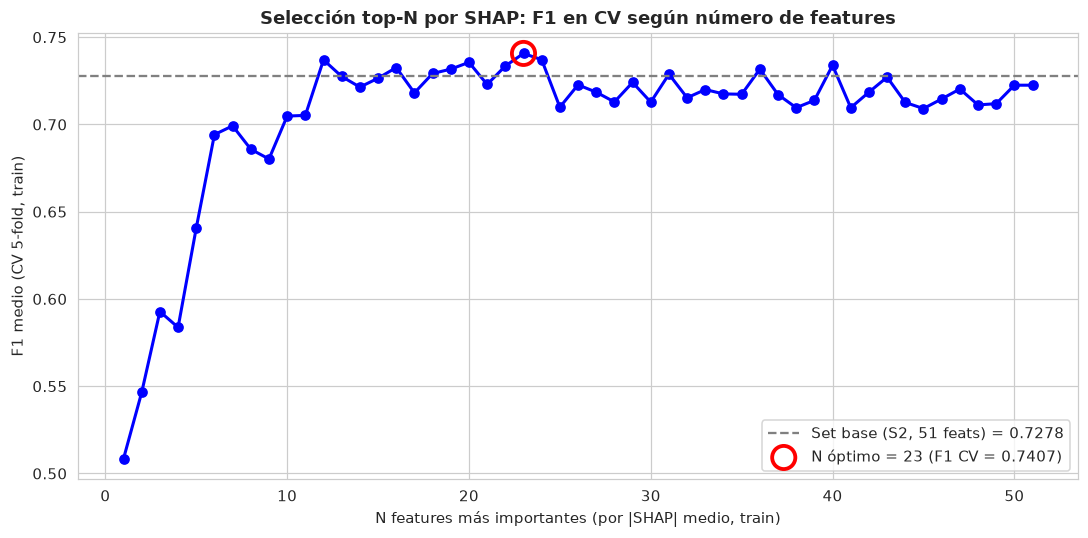


Selección SHAP: top-23 de 51 features | F1 CV = 0.7407 (set base 0.7278, Δ = +0.0129)
Selección MEJORÓ F1 CV → set final = top-23
Features seleccionadas: ['Ag_ppm', 'Sb_ppm', 'Sr_ppm', 'U_ppm', 'As_ppm', 'Te_ppm', 'Cs_ppm', 'Ta_ppm', 'Mg_per', 'Sn_ppm', 'Rb_ppm', 'Cu_ppm', 'Na_per', 'Y_ppm', 'Th_ppm', 'Be_ppm', 'Mo_ppm', 'Ni_ppm', 'Cr_ppm', 'La_ppm', 'Mn_ppm', 'kmeans_dist', 'Fe_per']


In [26]:
# ---- SHAP del set base (reentrenar si incluye cluster SHAP) ----
if SET_BASE != 'S2':
    print(f'Recalculando SHAP sobre el set base ({SET_BASE}) para rankear con justicia...')
    modelo_shap_base = crear_imbpipeline()
    modelo_shap_base.fit(XTR_BASE, y_train)
    scaler_base = modelo_shap_base.named_steps['sc']
    clf_base = modelo_shap_base.named_steps['clf']
    X_train_sc_base = pd.DataFrame(scaler_base.transform(XTR_BASE), columns=XTR_BASE.columns, index=XTR_BASE.index)
    try:
        explainer_base = shap.TreeExplainer(clf_base)
    except Exception:
        explainer_base = shap.Explainer(clf_base, X_train_sc_base.sample(min(100, len(X_train_sc_base)), random_state=SEED))
    sv_train_base = explainer_base(X_train_sc_base)
    imp_shap_base = pd.Series(np.abs(sv_train_base.values).mean(0), index=XTR_BASE.columns).sort_values(ascending=False)
    imp_shap_base.to_csv('outputs_sprint3/shap_importancias_set_base.csv', header=['shap_medio'])
    print(f'Top-10 features del set base por |SHAP| medio (train):')
    display(imp_shap_base.head(10).round(4).to_frame('|SHAP| medio (train)'))
else:
    imp_shap_base = imp_shap_train.copy()

# ---- Barrido top-N: F1 en CV según nº de features (decisión sin tocar el hold-out) ----
ranking_feats = list(imp_shap_base.index)
Ns = list(range(1, len(ranking_feats) + 1))
f1_topn = [f1_cv(XTR_BASE[ranking_feats[:n]]) for n in Ns]
tabla_topn = pd.DataFrame({'N': Ns, 'F1 CV': np.round(f1_topn, 4)})
tabla_topn.to_csv('outputs_sprint3/seleccion_topn.csv', index=False)

N_OPT = int(tabla_topn.loc[tabla_topn['F1 CV'].idxmax(), 'N'])
F1_TOPN = float(tabla_topn['F1 CV'].max())
FEATS_FINAL = ranking_feats[:N_OPT]
XTR_FINAL = XTR_BASE[FEATS_FINAL].copy()
XTE_FINAL = XTE_BASE[FEATS_FINAL].copy()
SELECCION_MEJORO = F1_TOPN > F1_CV_SET_BASE + 0.001

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(tabla_topn['N'], tabla_topn['F1 CV'], 'o-', color='blue', lw=2, markersize=6)
ax.axhline(F1_CV_SET_BASE, ls='--', color='gray',
           label=f'Set base ({SET_BASE}, {XTR_BASE.shape[1]} feats) = {F1_CV_SET_BASE:.4f}')
ax.scatter([N_OPT], [F1_TOPN], s=230, facecolors='none', edgecolors='red', linewidths=2.5,
           zorder=5, label=f'N óptimo = {N_OPT} (F1 CV = {F1_TOPN:.4f})')
ax.set_xlabel('N features más importantes (por |SHAP| medio, train)')
ax.set_ylabel('F1 medio (CV 5-fold, train)')
ax.set_title('Selección top-N por SHAP: F1 en CV según número de features', fontweight='bold')
ax.legend()
plt.tight_layout(); plt.savefig('outputs_sprint3/seleccion_topn.png', bbox_inches='tight'); plt.show()

print(f'\nSelección SHAP: top-{N_OPT} de {XTR_BASE.shape[1]} features | F1 CV = {F1_TOPN:.4f} '
      f'(set base {F1_CV_SET_BASE:.4f}, Δ = {F1_TOPN - F1_CV_SET_BASE:+.4f})')
if SELECCION_MEJORO:
    print(f'Selección MEJORÓ F1 CV → set final = top-{N_OPT}')
else:
    print(f'Selección NO mejoró F1 CV → set final = set base completo')
print(f'Features seleccionadas: {FEATS_FINAL}')

## Optuna

In [27]:
def espacio_params(mod, trial):
    # Rangos a-priori del Sprint 2 (alrededor de defaults, no centrados en optimos de CV)
    if mod == 'KNN':
        return {'n_neighbors': trial.suggest_int('n_neighbors', 3, 15, step=2),
                'weights':     trial.suggest_categorical('weights', ['uniform', 'distance']),
                'p':           trial.suggest_int('p', 1, 2)}
    if mod == 'Reg. Logística':
        return {'C':            trial.suggest_float('C', 0.1, 10.0, log=True),
                'class_weight': trial.suggest_categorical('class_weight', [None, 'balanced'])}
    if mod == 'SVM (RBF)':
        return {'C':            trial.suggest_float('C', 0.5, 10.0, log=True),
                'class_weight': trial.suggest_categorical('class_weight', [None, 'balanced'])}
    if mod == 'MLP':
        return {'hidden_layer_sizes': trial.suggest_categorical(
                    'hidden_layer_sizes', [(100,), (150,), (200,), (100, 50), (150, 75)]),
                'alpha':              trial.suggest_float('alpha', 1e-5, 1e-3, log=True),
                'learning_rate_init': trial.suggest_float('learning_rate_init', 3e-4, 3e-3, log=True)}
    if mod == 'Árbol de Decisión':
        return {'min_samples_split': trial.suggest_int('min_samples_split', 2, 12),
                'min_samples_leaf':  trial.suggest_int('min_samples_leaf',  1, 8),
                'criterion':         trial.suggest_categorical('criterion', ['gini', 'entropy'])}
    if mod == 'Random Forest':
        return {'n_estimators':      trial.suggest_int('n_estimators', 100, 300),
                'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
                'min_samples_leaf':  trial.suggest_int('min_samples_leaf',  1, 4),
                'max_features':      trial.suggest_categorical('max_features', ['sqrt', 'log2'])}
    if mod == 'ExtraTrees':
        return {'n_estimators':      trial.suggest_int('n_estimators', 100, 300),
                'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
                'min_samples_leaf':  trial.suggest_int('min_samples_leaf',  1, 4),
                'max_features':      trial.suggest_categorical('max_features', ['sqrt', 'log2'])}
    if mod == 'HistGradientBoosting':
        return {'max_iter':          trial.suggest_int('max_iter', 80, 300),
                'learning_rate':     trial.suggest_float('learning_rate', 0.03, 0.2, log=True),
                'max_leaf_nodes':    trial.suggest_int('max_leaf_nodes', 15, 63),
                'min_samples_leaf':  trial.suggest_int('min_samples_leaf', 10, 40),
                'l2_regularization': trial.suggest_float('l2_regularization', 0.0, 1.0)}
    if mod == 'XGBoost':
        return {'n_estimators':     trial.suggest_int('n_estimators',   80,  300),
                'max_depth':        trial.suggest_int('max_depth',       3,    8),
                'learning_rate':    trial.suggest_float('learning_rate', 0.05, 0.3, log=True),
                'subsample':        trial.suggest_float('subsample',     0.7, 1.0),
                'colsample_bytree': trial.suggest_float('colsample_bytree', 0.7, 1.0),
                'min_child_weight': trial.suggest_float('min_child_weight', 1.0, 5.0),
                'gamma':            trial.suggest_float('gamma',          0.0, 0.5),
                'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1.0, 5.0)}
    if mod == 'LightGBM':
        return {'n_estimators':      trial.suggest_int('n_estimators',    80, 300),
                'num_leaves':        trial.suggest_int('num_leaves',       20,  63),
                'learning_rate':     trial.suggest_float('learning_rate',  0.03, 0.2, log=True),
                'subsample':         trial.suggest_float('subsample',      0.7, 1.0),
                'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.7, 1.0),
                'min_child_samples': trial.suggest_int('min_child_samples', 10,  40),
                'reg_lambda':        trial.suggest_float('reg_lambda',      0.0, 1.0)}
    if mod == 'CatBoost':
        return {'iterations':    trial.suggest_int('iterations',     80,  300),
                'depth':         trial.suggest_int('depth',           4,   8),
                'learning_rate': trial.suggest_float('learning_rate', 0.02, 0.1, log=True),
                'l2_leaf_reg':   trial.suggest_float('l2_leaf_reg',   1.0,  5.0),
                'subsample':     trial.suggest_float('subsample',     0.7, 1.0)}
    raise ValueError(mod)

N_TRIALS_S3 = 100
print(f'Ejecutando Optuna ({N_TRIALS_S3} trials) sobre el set final ({MODELO_GANADOR})...')

def objective_s3(trial):
    return f1_cv(XTR_FINAL, params=espacio_params(MODELO_GANADOR, trial))

t0 = time.time()
study_s3 = optuna.create_study(direction='maximize', sampler=TPESampler(seed=SEED))
study_s3.optimize(objective_s3, n_trials=N_TRIALS_S3, show_progress_bar=False)
OPTUNA_PARAMS = dict(study_s3.best_params)
F1_CV_OPTUNA = float(study_s3.best_value)
print(f'Optuna finalizado ({time.time()-t0:.0f}s) | mejor F1 CV = {F1_CV_OPTUNA:.4f}')
print(f'  Params: {OPTUNA_PARAMS}')
with open('outputs_sprint3/optuna_s3_best_params.json', 'w') as f:
    json.dump(OPTUNA_PARAMS, f, indent=2, ensure_ascii=False)

# ---- Comparación defaults vs Optuna (decisión por F1 CV) ----
res_defaults = entrenar_evaluar(XTR_FINAL, XTE_FINAL, PARAMS_GANADOR)
res_optuna   = entrenar_evaluar(XTR_FINAL, XTE_FINAL, OPTUNA_PARAMS)

tabla_comp = pd.DataFrame({
    'Candidato': [f'Set final ({N_OPT} feats) + defaults S2', f'Set final ({N_OPT} feats) + Optuna'],
    'F1 CV':     [round(F1_TOPN, 4), round(F1_CV_OPTUNA, 4)],
    'F1 hold-out': [round(res_defaults['F1'], 4), round(res_optuna['F1'], 4)],
}).set_index('Candidato')
tabla_comp.to_csv('outputs_sprint3/defaults_vs_optuna.csv')
display(tabla_comp)

MEJOR_CONFIG = 'defaults S2' if F1_TOPN >= F1_CV_OPTUNA else 'Optuna'
PARAMS_FINAL = PARAMS_GANADOR if MEJOR_CONFIG == 'defaults S2' else OPTUNA_PARAMS
F1_CV_FINAL  = F1_TOPN if MEJOR_CONFIG == 'defaults S2' else F1_CV_OPTUNA
RES_PRE_CAL  = res_defaults if MEJOR_CONFIG == 'defaults S2' else res_optuna

print(f'\n-> MEJOR configuración (por F1 CV): {MEJOR_CONFIG}')
print(f'   F1 CV = {F1_CV_FINAL:.4f} | F1 hold-out = {RES_PRE_CAL["F1"]:.4f}')
print(f'   Params: {PARAMS_FINAL if PARAMS_FINAL else "(defaults)"}')

Ejecutando Optuna (100 trials) sobre el set final (HistGradientBoosting)...


Optuna finalizado (229s) | mejor F1 CV = 0.7550
  Params: {'max_iter': 289, 'learning_rate': 0.18175581564163837, 'max_leaf_nodes': 16, 'min_samples_leaf': 33, 'l2_regularization': 0.33524616125194756}


,F1 CV,F1 hold-out
Candidato,,
Set final (23 feats) + defaults S2,0.7407,0.7963
Set final (23 feats) + Optuna,0.7550,0.8037



-> MEJOR configuración (por F1 CV): Optuna
   F1 CV = 0.7550 | F1 hold-out = 0.8037
   Params: {'max_iter': 289, 'learning_rate': 0.18175581564163837, 'max_leaf_nodes': 16, 'min_samples_leaf': 33, 'l2_regularization': 0.33524616125194756}


## Control de overfitting

,Conjunto,F1,Gap vs train
0,Train (resustitución),1.0000,0.0000
1,CV 5-fold (train),0.7550,-0.2450
2,Hold-out (20%),0.8037,-0.1963


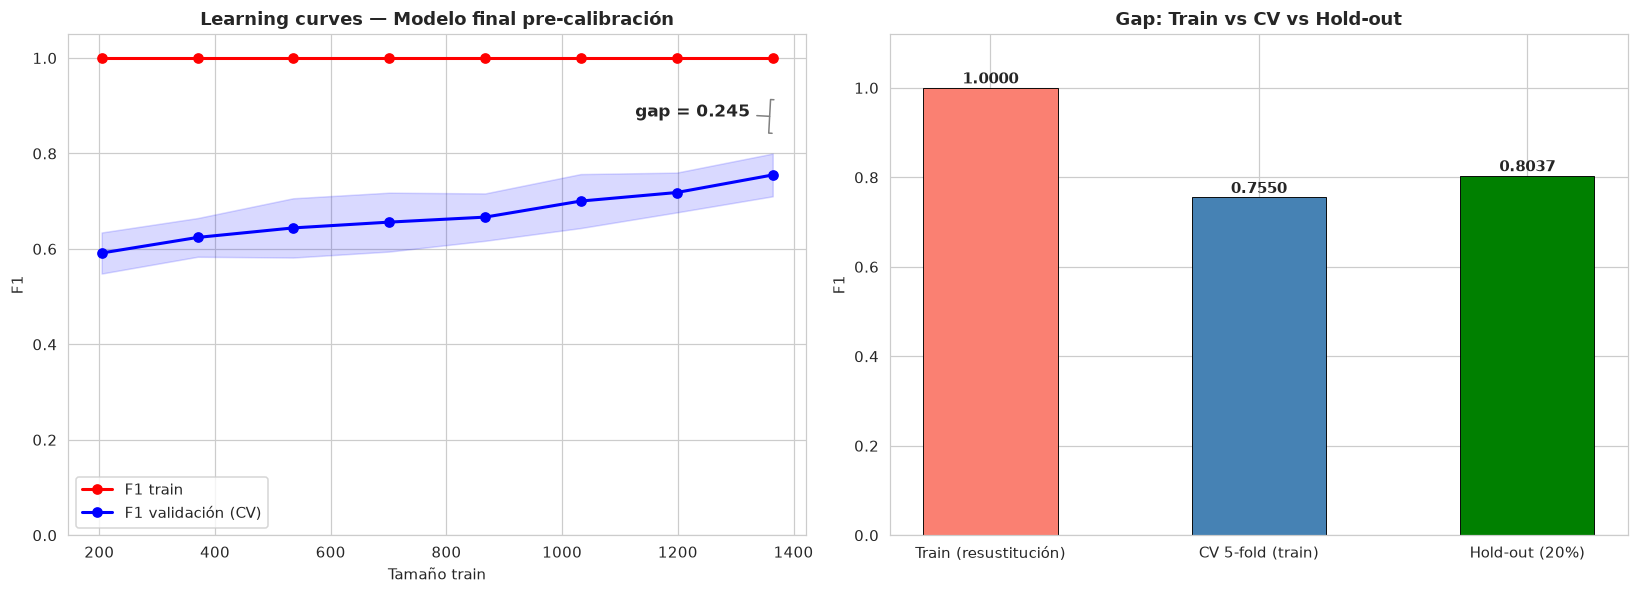

In [28]:
modelo_lc2 = crear_imbpipeline(PARAMS_FINAL)
sizes2, tr2, va2 = learning_curve(
    modelo_lc2, XTR_FINAL, y_train, cv=CV5, scoring='f1',
    train_sizes=np.linspace(0.15, 1.0, 8), n_jobs=-1, random_state=SEED)
tr2_mu, va2_mu = tr2.mean(1), va2.mean(1)
gap2 = tr2_mu[-1] - va2_mu[-1]

clf_gap2 = crear_imbpipeline(PARAMS_FINAL)
clf_gap2.fit(XTR_FINAL, y_train)
f1_train2 = f1_score(y_train, clf_gap2.predict(XTR_FINAL))

tabla_gap2 = pd.DataFrame({
    'Conjunto': ['Train (resustitución)', 'CV 5-fold (train)', 'Hold-out (20%)'],
    'F1': [round(f1_train2, 4), round(F1_CV_FINAL, 4), round(RES_PRE_CAL['F1'], 4)]})
tabla_gap2['Gap vs train'] = (tabla_gap2['F1'] - f1_train2).round(4)
tabla_gap2.to_csv('outputs_sprint3/gap_final.csv', index=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5.5))
ax1.plot(sizes2, tr2_mu, 'o-', color='red', lw=2, label='F1 train')
ax1.fill_between(sizes2, tr2.mean(1)-tr2.std(1), tr2.mean(1)+tr2.std(1), alpha=.15, color='red')
ax1.plot(sizes2, va2_mu, 'o-', color='blue', lw=2, label='F1 validación (CV)')
ax1.fill_between(sizes2, va2.mean(1)-va2.std(1), va2.mean(1)+va2.std(1), alpha=.15, color='blue')
ax1.annotate(f'gap = {gap2:.3f}', xy=(sizes2[-1], (tr2_mu[-1]+va2_mu[-1])/2),
             xytext=(-90,0), textcoords='offset points', fontsize=11, fontweight='bold',
             arrowprops=dict(arrowstyle='-[', color='gray'))
ax1.set_xlabel('Tamaño train'); ax1.set_ylabel('F1'); ax1.set_ylim(0,1.05)
ax1.set_title(f'Learning curves — Modelo final pre-calibración', fontweight='bold'); ax1.legend()
display(tabla_gap2)
# Barras de gap
conjs = tabla_gap2['Conjunto'].tolist(); vals = tabla_gap2['F1'].tolist()
ax2.bar(conjs, vals, color=['salmon','steelblue','green'], edgecolor='black', lw=.6, width=.5)
for i, v in enumerate(vals):
    ax2.text(i, v+.01, f'{v:.4f}', ha='center', fontweight='bold')
ax2.set_ylabel('F1'); ax2.set_ylim(0, max(vals)+.12)
ax2.set_title('Gap: Train vs CV vs Hold-out', fontweight='bold')
plt.tight_layout(); plt.savefig('outputs_sprint3/gap_final_plot.png', bbox_inches='tight'); plt.show()

## Calibración y ajuste de umbral

  Sin calibrar: Brier OOF = 0.0511 (3s)
  Sigmoid (Platt): Brier OOF = 0.0467 (12s)
  Isotónica: Brier OOF = 0.0475 (12s)
-> Calibración elegida: Sigmoid (Platt)


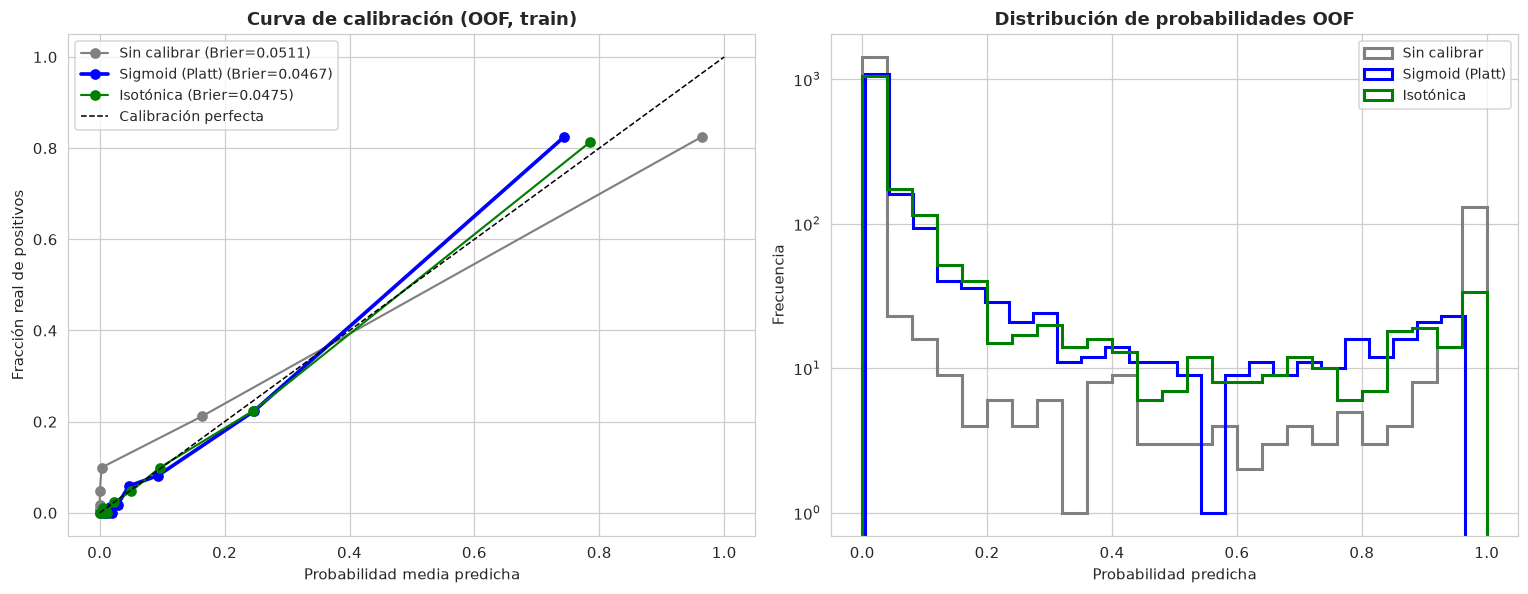

In [29]:
variantes_cal = {
    'Sin calibrar': crear_imbpipeline(PARAMS_FINAL),
    'Sigmoid (Platt)': CalibratedClassifierCV(crear_imbpipeline(PARAMS_FINAL), method='sigmoid', cv=CV5),
    'Isotónica': CalibratedClassifierCV(crear_imbpipeline(PARAMS_FINAL), method='isotonic', cv=CV5),
}

briers_oof, prob_oof_cal = {}, {}
for nom, clf in variantes_cal.items():
    t0 = time.time()
    p_oof = cross_val_predict(clf, XTR_FINAL, y_train, cv=CV5,
                              method='predict_proba', n_jobs=-1)[:, 1]
    briers_oof[nom] = brier_score_loss(y_train, p_oof)
    prob_oof_cal[nom] = p_oof
    print(f'  {nom}: Brier OOF = {briers_oof[nom]:.4f} ({time.time()-t0:.0f}s)')
MEJOR_CAL = min(briers_oof, key=briers_oof.get)
print(f'-> Calibración elegida: {MEJOR_CAL}')

# Curvas de calibración (OOF en train)
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
cal_colors = {'Sin calibrar': 'gray', 'Sigmoid (Platt)': 'blue', 'Isotónica': 'green'}
for nom, p_oof in prob_oof_cal.items():
    frac_pos, media_pred = calibration_curve(y_train, p_oof, n_bins=10, strategy='quantile')
    lw = 2.4 if nom == MEJOR_CAL else 1.4
    axes[0].plot(media_pred, frac_pos, 'o-', color=cal_colors[nom], lw=lw,
                 label=f'{nom} (Brier={briers_oof[nom]:.4f})')
    axes[1].hist(p_oof, bins=25, histtype='step', lw=2, color=cal_colors[nom], label=nom)
axes[0].plot([0, 1], [0, 1], '--', color='black', lw=1, label='Calibración perfecta')
axes[0].set_xlabel('Probabilidad media predicha'); axes[0].set_ylabel('Fracción real de positivos')
axes[0].set_title('Curva de calibración (OOF, train)', fontweight='bold'); axes[0].legend(fontsize=9)
axes[1].set_xlabel('Probabilidad predicha'); axes[1].set_ylabel('Frecuencia'); axes[1].set_yscale('log')
axes[1].set_title('Distribución de probabilidades OOF', fontweight='bold'); axes[1].legend(fontsize=9)
plt.tight_layout(); plt.savefig('outputs_sprint3/calibracion.png', bbox_inches='tight'); plt.show()

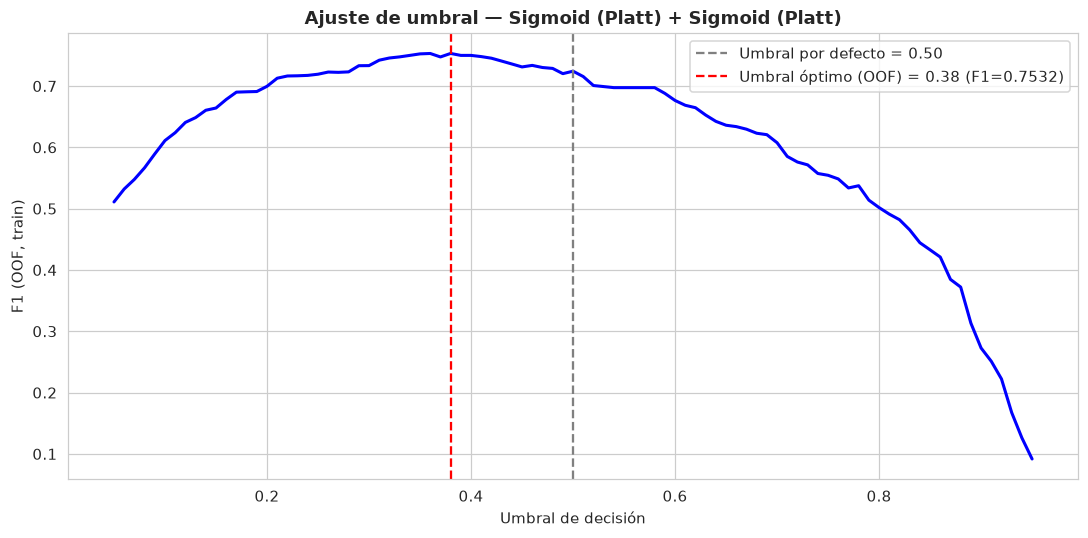

Umbral óptimo: 0.38 (F1 OOF = 0.7532) vs 0.50 (F1 OOF = 0.7242)


In [30]:
# ---- Ajuste de umbral sobre OOF de la variante elegida ----
p_oof = prob_oof_cal[MEJOR_CAL]
umbrales = np.arange(0.05, 0.96, 0.01)
f1s_u = [f1_score(y_train, (p_oof >= u).astype(int)) for u in umbrales]
UMBRAL_OPT = float(umbrales[int(np.argmax(f1s_u))])

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(umbrales, f1s_u, color='blue', lw=2)
ax.axvline(0.5, ls='--', color='gray', label='Umbral por defecto = 0.50')
ax.axvline(UMBRAL_OPT, ls='--', color='red',
           label=f'Umbral óptimo (OOF) = {UMBRAL_OPT:.2f} (F1={max(f1s_u):.4f})')
ax.set_xlabel('Umbral de decisión'); ax.set_ylabel('F1 (OOF, train)')
ax.set_title(f'Ajuste de umbral — {MEJOR_CAL} + {MEJOR_CAL}', fontweight='bold')
ax.legend()
plt.tight_layout(); plt.savefig('outputs_sprint3/ajuste_umbral.png', bbox_inches='tight'); plt.show()
print(f'Umbral óptimo: {UMBRAL_OPT:.2f} (F1 OOF = {max(f1s_u):.4f}) vs 0.50 '
      f'(F1 OOF = {f1_score(y_train, (p_oof >= 0.5).astype(int)):.4f})')

MODELO FINAL: Sigmoid (Platt) + Sigmoid (Platt) + umbral 0.38
  F1 (umbral 0.38): 0.8000
  F1 (umbral 0.50):  0.7677
  F1: 0.8
  Accuracy: 0.9485
  Precision: 0.7586
  Recall: 0.8462
  AUC-ROC: 0.9643


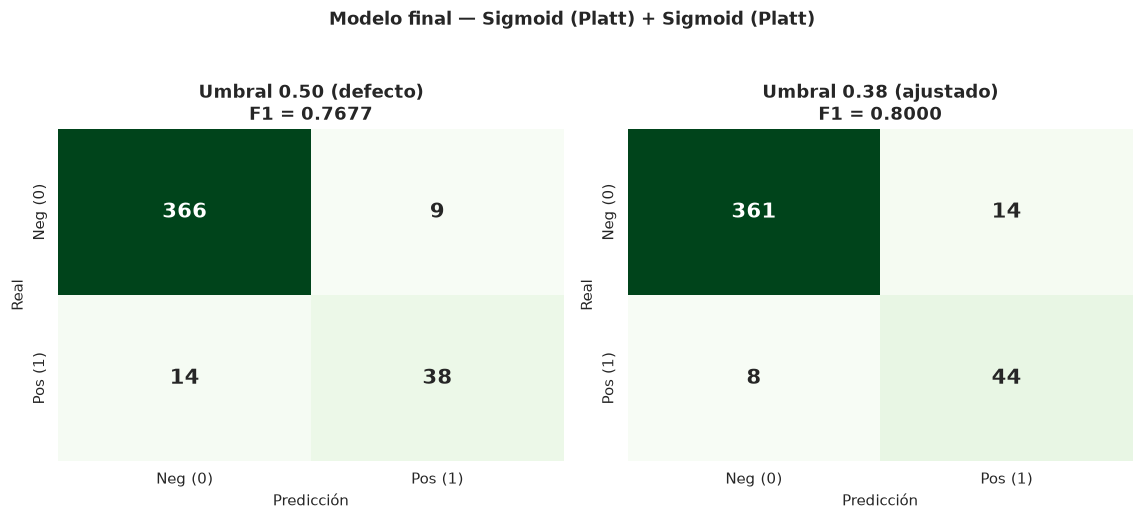

In [31]:
# ---- Evaluación final en hold-out (UNA sola vez) ----
clf_final = variantes_cal[MEJOR_CAL]
if MEJOR_CAL != 'Sin calibrar':
    # CalibratedClassifierCV ya clonado en variantes_cal; re-crear para fit limpio
    metodo_cal = 'sigmoid' if 'Sigmoid' in MEJOR_CAL else 'isotonic'
    clf_final = CalibratedClassifierCV(crear_imbpipeline(PARAMS_FINAL), method=metodo_cal, cv=CV5)
else:
    clf_final = crear_imbpipeline(PARAMS_FINAL)
clf_final.fit(XTR_FINAL, y_train)
prob_final = clf_final.predict_proba(XTE_FINAL)[:, 1]
pred_final = (prob_final >= UMBRAL_OPT).astype(int)
pred_05 = (prob_final >= 0.5).astype(int)

RES_FINAL = {m: round(v, 4) for m, v in {
    'F1': f1_score(y_test, pred_final), 'Accuracy': accuracy_score(y_test, pred_final),
    'Precision': precision_score(y_test, pred_final, zero_division=0),
    'Recall': recall_score(y_test, pred_final), 'AUC-ROC': roc_auc_score(y_test, prob_final)}.items()}
RES_05 = {'F1': f1_score(y_test, pred_05)}
print(f'MODELO FINAL: {MEJOR_CAL} + {MEJOR_CAL} + umbral {UMBRAL_OPT:.2f}')
print(f'  F1 (umbral {UMBRAL_OPT:.2f}): {RES_FINAL["F1"]:.4f}')
print(f'  F1 (umbral 0.50):  {RES_05["F1"]:.4f}')
for m in METRICAS:
    print(f'  {m}: {RES_FINAL[m]}')

# ---- Matrices de confusión ----
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.5))
for ax, (pred, tit) in zip(axes, [(pred_05, 'Umbral 0.50 (defecto)'),
                                  (pred_final, f'Umbral {UMBRAL_OPT:.2f} (ajustado)')]):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cbar=False, ax=ax, cmap='Greens',
                xticklabels=['Neg (0)', 'Pos (1)'], yticklabels=['Neg (0)', 'Pos (1)'],
                annot_kws={'size': 14, 'fontweight': 'bold'})
    ax.set_title(f'{tit}\nF1 = {f1_score(y_test, pred):.4f}', fontweight='bold')
    ax.set_xlabel('Predicción'); ax.set_ylabel('Real')
plt.suptitle(f'Modelo final — {MEJOR_CAL} + {MEJOR_CAL}', fontweight='bold', y=1.04)
plt.tight_layout(); plt.savefig('outputs_sprint3/final_matrices_confusion.png', bbox_inches='tight'); plt.show()

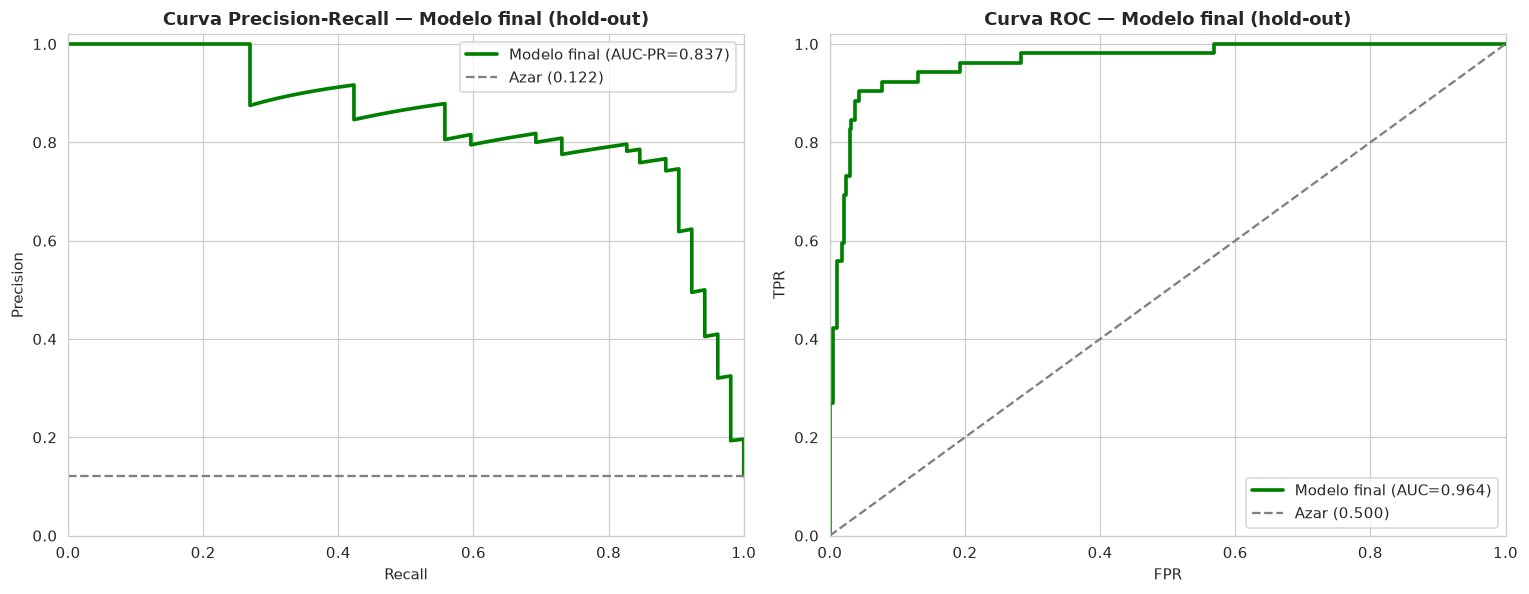

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
p, r, _ = precision_recall_curve(y_test, prob_final)
axes[0].plot(r, p, color='green', lw=2.4, label=f'Modelo final (AUC-PR={auc(r, p):.3f})')
axes[0].hlines(y_test.mean(), 0, 1, colors='gray', linestyles='--', label=f'Azar ({y_test.mean():.3f})')
axes[0].set_xlabel('Recall'); axes[0].set_ylabel('Precision'); axes[0].set_xlim(0, 1); axes[0].set_ylim(0, 1.02)
axes[0].set_title('Curva Precision-Recall — Modelo final (hold-out)', fontweight='bold'); axes[0].legend()
fpr, tpr, _ = roc_curve(y_test, prob_final)
axes[1].plot(fpr, tpr, color='green', lw=2.4, label=f'Modelo final (AUC={RES_FINAL["AUC-ROC"]:.3f})')
axes[1].plot([0, 1], [0, 1], '--', color='gray', label='Azar (0.500)')
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR'); axes[1].set_xlim(0, 1); axes[1].set_ylim(0, 1.02)
axes[1].set_title('Curva ROC — Modelo final (hold-out)', fontweight='bold'); axes[1].legend(loc='lower right')
plt.tight_layout(); plt.savefig('outputs_sprint3/final_curvas_pr_roc.png', bbox_inches='tight'); plt.show()

## Resumen

,Hito,F1 (hold-out),Δ vs Sprint 2
0,Sprint 0 (baseline),0.7629,-0.0595
1,Sprint 1 (ganador),0.7736,-0.0488
2,Sprint 2 (ganador),0.8224,0.0000
3,Sprint 3 — pre-calibración,0.8037,-0.0187
4,"Sprint 3 — FINAL (+Sigmoid (Platt), umbral 0.38)",0.8000,-0.0224


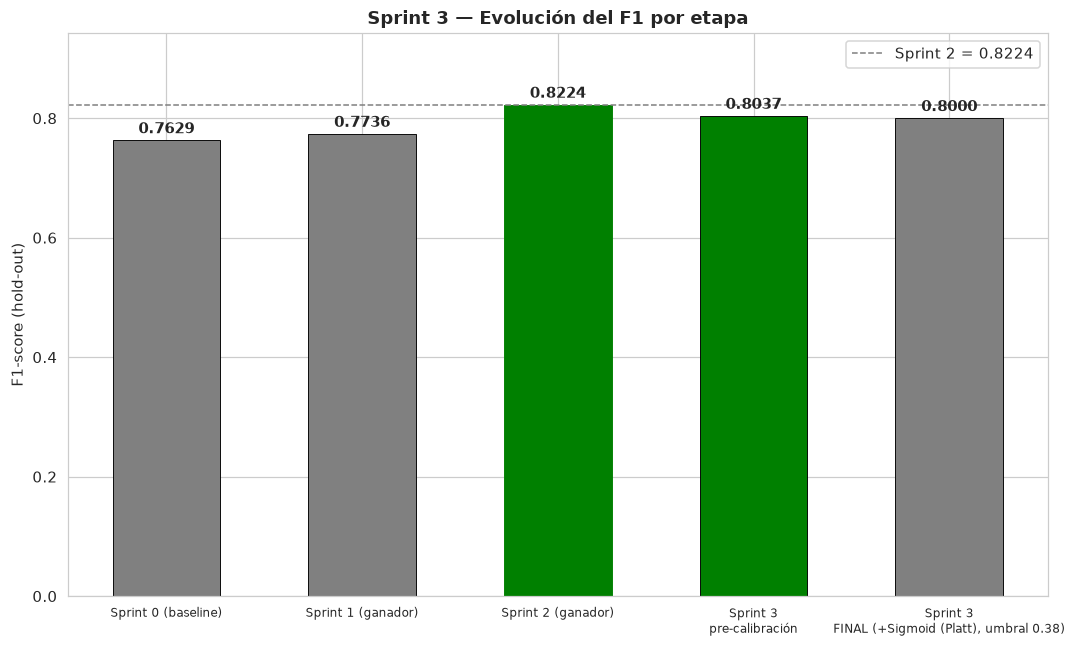

════════════ RESUMEN SPRINT 3 ════════════
Paso 1: Clustering SHAP (10 elem. no-econ., k=7): F1 CV = 0.7105 (no mejoró)
   Set base resultante: 0.7278 S2 (51 features)
Paso 2: Selección SHAP: top-23 | F1 CV = 0.7407 (mejoró)
Paso 3: Optuna (100 trials): F1 CV = 0.7550
   Config elegida (por F1 CV): Optuna
Modelo pre-calibración: HistGradientBoosting (Optuna, 23 feats) -> F1 hold-out = 0.8037
Calibración: Sigmoid (Platt) | Umbral: 0.38

MODELO FINAL: HistGradientBoosting + Optuna + top-23 + Sigmoid (Platt) + umbral 0.38
  F1 final = 0.8000 (Sprint 2 = 0.8224, Δ = -0.0224)

Evolución del proyecto:
  Sprint 0 = 0.7629 -> Sprint 1 = 0.7736 -> Sprint 2 = 0.8224 -> Sprint 3 = 0.8000

Siguiente paso (Sprint 4): slices de errores y mitigación.


In [33]:
# ---- Tabla de cierre ----
hitos = [
    ('Sprint 0 (baseline)', F1_SPRINT0),
    ('Sprint 1 (ganador)', F1_SPRINT1),
    ('Sprint 2 (ganador)', F1_SPRINT2),
    ('Sprint 3 — pre-calibración', RES_PRE_CAL['F1']),
    (f'Sprint 3 — FINAL (+{MEJOR_CAL}, umbral {UMBRAL_OPT:.2f})', RES_FINAL['F1']),
]
tabla_cierre = pd.DataFrame(hitos, columns=['Hito', 'F1 (hold-out)']).round(4)
tabla_cierre['Δ vs Sprint 2'] = (tabla_cierre['F1 (hold-out)'] - F1_SPRINT2).round(4)
tabla_cierre.to_csv('outputs_sprint3/final_cierre_sprint3.csv', index=False)
display(tabla_cierre)

# ---- Gráfico de evolución ----
fig, ax = plt.subplots(figsize=(10, 6))
nombres = [h[0] for h in hitos]; valores = [h[1] for h in hitos]
colores = ['gray', 'gray', 'steelblue', 'green']
bars = ax.bar(range(len(hitos)), valores, color=colores, width=0.55, edgecolor='black', lw=0.6)
i_max = int(np.argmax(valores)); bars[i_max].set_color('green')
for b, v in zip(bars, valores):
    ax.text(b.get_x() + b.get_width()/2, v + 0.012, f'{v:.4f}', ha='center', fontweight='bold')
ax.axhline(F1_SPRINT2, ls='--', color='gray', lw=1, label=f'Sprint 2 = {F1_SPRINT2:.4f}')
ax.set_xticks(range(len(hitos))); ax.set_xticklabels([n.replace(' — ', '\n') for n in nombres], fontsize=8)
ax.set_ylabel('F1-score (hold-out)'); ax.set_ylim(0, max(valores) + 0.12)
ax.set_title('Sprint 3 — Evolución del F1 por etapa', fontweight='bold'); ax.legend()
plt.tight_layout(); plt.savefig('outputs_sprint3/evolucion_f1.png', bbox_inches='tight'); plt.show()

# ---- JSON de resumen (compatible con Sprint 4) ----
resumen3 = {
    'modelo_base': MODELO_GANADOR,
    'set_final_features': list(XTR_FINAL.columns),
    'n_features': int(XTR_FINAL.shape[1]),
    'paso1_cluster_shap': {
        'ejecutado': bool(CLUSTER_SHAP_OK),
        'elementos_materia_prima': list(cand_noecon) if CLUSTER_SHAP_OK else [],
        'k_kmeans': K_SHAP,
        'f1_cv': round(F1_CV_CLUSHAP, 4) if CLUSTER_SHAP_OK else None,
        'mejoro': bool(CLUSTER_SHAP_MEJORO),
        'set_base_resultante': SET_BASE,
    },
    'paso2_seleccion_shap': {
        'n_opt': int(N_OPT),
        'f1_cv': round(F1_TOPN, 4),
        'mejoro': bool(SELECCION_MEJORO),
        'features': list(FEATS_FINAL),
    },
    'paso3_optuna': {
        'n_trials': int(N_TRIALS_S3),
        'f1_cv_optuna': round(F1_CV_OPTUNA, 4),
        'params_optuna': OPTUNA_PARAMS,
        'config_elegida': MEJOR_CONFIG,
    },
    'params_finales': PARAMS_FINAL,
    'balanceo': BALANCEO_GANADOR,
    'calibracion': MEJOR_CAL,
    'umbral': UMBRAL_OPT,
    'f1_final': RES_FINAL['F1'],
    'f1_sprint2': F1_SPRINT2,
    'mejora_vs_sprint2': round(RES_FINAL['F1'] - F1_SPRINT2, 4),
    'metricas_finales': RES_FINAL,
    'ratios_sprint2': {k: list(v) for k, v in RATIOS_S2.items()},
}
with open('outputs_sprint3/final_resumen_sprint3.json', 'w') as f:
    json.dump(resumen3, f, indent=2, ensure_ascii=False)

print('════════════ RESUMEN SPRINT 3 ════════════')
print(f'Paso 1: Clustering SHAP ({len(cand_noecon)} elem. no-econ., k={K_SHAP}): '
      f'F1 CV = {F1_CV_CLUSHAP:.4f} ({"mejoró" if CLUSTER_SHAP_MEJORO else "no mejoró"})')
print(f'   Set base resultante: {F1_CV_BASE:.4f} {SET_BASE} ({XTR_BASE.shape[1]} features)')
print(f'Paso 2: Selección SHAP: top-{N_OPT} | F1 CV = {F1_TOPN:.4f} '
      f'({"mejoró" if SELECCION_MEJORO else "no mejoró"})')
print(f'Paso 3: Optuna ({N_TRIALS_S3} trials): F1 CV = {F1_CV_OPTUNA:.4f}')
print(f'   Config elegida (por F1 CV): {MEJOR_CONFIG}')
print(f'Modelo pre-calibración: {MODELO_GANADOR} ({MEJOR_CONFIG}, {N_OPT} feats) -> F1 hold-out = {RES_PRE_CAL["F1"]:.4f}')
print(f'Calibración: {MEJOR_CAL} | Umbral: {UMBRAL_OPT:.2f}')
print(f'\nMODELO FINAL: {MODELO_GANADOR} + {MEJOR_CONFIG} + top-{N_OPT} + {MEJOR_CAL} + umbral {UMBRAL_OPT:.2f}')
print(f'  F1 final = {RES_FINAL["F1"]:.4f} (Sprint 2 = {F1_SPRINT2:.4f}, Δ = {RES_FINAL["F1"] - F1_SPRINT2:+.4f})')
print(f'\nEvolución del proyecto:')
print(f'  Sprint 0 = {F1_SPRINT0:.4f} -> Sprint 1 = {F1_SPRINT1:.4f} -> Sprint 2 = {F1_SPRINT2:.4f} -> Sprint 3 = {RES_FINAL["F1"]:.4f}')
print(f'\nSiguiente paso (Sprint 4): slices de errores y mitigación.')